In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")


In [16]:
from sklearn.datasets import make_moons

X ,y  = make_moons(n_samples= 1000 , noise = 0.2 , random_state=42 , shuffle = True)


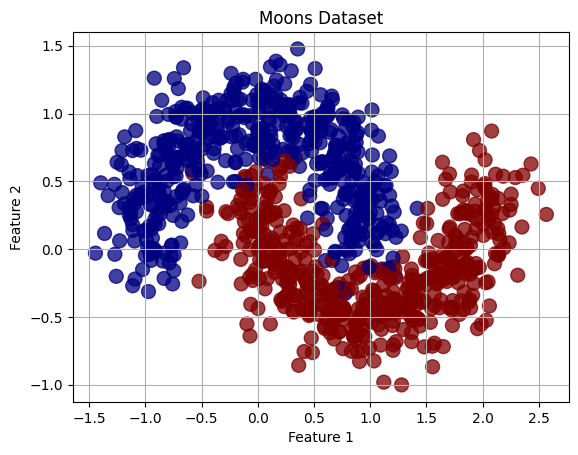

In [17]:
plt.scatter(X[:,0] , X[:,1] , c = y , cmap = 'jet' , s = 100 , alpha = 0.75)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.grid()
plt.show()

In [18]:
import tensorflow as tf 
from tensorflow import keras 
from keras import Sequential
from keras.layers import Dense  , Dropout , BatchNormalization


In [19]:
model = Sequential()

model.add(Dense(2 , activation='sigmoid' , input_dim = 2))
model.add(Dense(1 , activation='sigmoid'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.get_weights()

[array([[ 1.0806855 ,  0.31394565],
        [-0.04728854, -1.1724161 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.65509045],
        [-1.19717   ]], dtype=float32),
 array([0.], dtype=float32)]

In [26]:
initial_weights = model.get_weights()


In [27]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5    # -- this represents the inital weights of the first layer
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5      # -- this represents the inital bias of the first layers 
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5      # -- this represents the inital weights of the second layer
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5      # -- this represents the inital bias of the second layers


In [30]:
model.set_weights(initial_weights)

In [31]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [32]:

model.compile(loss = 'binary_crossentropy' , optimizer = 'adam' , metrics = ['accuracy'])

In [33]:

history = model.fit(X , y , epochs =100 , validation_split=0.2 , verbose = 1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5013 - loss: 0.8477 - val_accuracy: 0.4950 - val_loss: 0.8439
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.8307 - val_accuracy: 0.4950 - val_loss: 0.8274
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.8152 - val_accuracy: 0.4950 - val_loss: 0.8122
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.8006 - val_accuracy: 0.4950 - val_loss: 0.7986
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.7874 - val_accuracy: 0.4950 - val_loss: 0.7861
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.7756 - val_accuracy: 0.4950 - val_loss: 0.7744
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.7646 - val_accuracy: 0.4950 - val_loss: 0.7641
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5013 - loss: 0.7550 - val_accuracy: 0.4950 - v

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 930us/step


<Axes: >

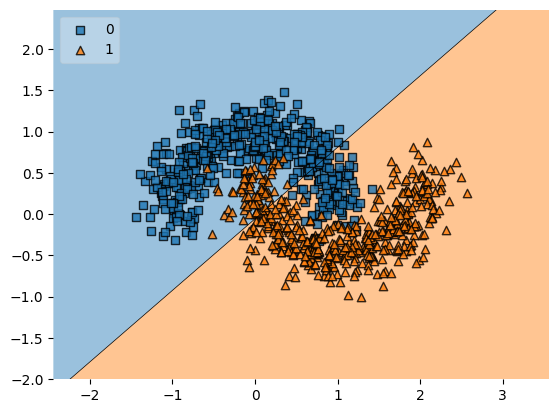

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [35]:
model2 = Sequential()

model2.add(Dense(10 , activation= 'sigmoid' , input_dim = 2 ))
model2.add(Dense(1 , activation='sigmoid'))

model2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Set parameters to 0
model2.get_weights()

[array([[ 0.35257405, -0.14941663,  0.17840189, -0.3885626 ,  0.2212143 ,
          0.02059782,  0.07401222, -0.32750732, -0.41003606, -0.25092852],
        [-0.55904186,  0.5284329 , -0.54480076,  0.39355212,  0.00768489,
          0.08689654, -0.4463641 ,  0.15839458, -0.65063894, -0.46870583]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.4390021 ],
        [-0.4282224 ],
        [ 0.5165003 ],
        [ 0.03003693],
        [-0.2349428 ],
        [-0.34440863],
        [ 0.41538113],
        [ 0.24504822],
        [-0.50031567],
        [ 0.01538777]], dtype=float32),
 array([0.], dtype=float32)]

In [37]:
initial_weights = model2.get_weights()

In [38]:
initial_weights[0] = np.zeros(model2.get_weights()[0].shape)
initial_weights[1] = np.zeros(model2.get_weights()[1].shape)
initial_weights[2] = np.zeros(model2.get_weights()[2].shape)
initial_weights[3] = np.zeros(model2.get_weights()[3].shape)

In [39]:
# this is zero weights initilization 
# all those nodes will be considered as one nodes 

model2.get_weights()


[array([[ 0.35257405, -0.14941663,  0.17840189, -0.3885626 ,  0.2212143 ,
          0.02059782,  0.07401222, -0.32750732, -0.41003606, -0.25092852],
        [-0.55904186,  0.5284329 , -0.54480076,  0.39355212,  0.00768489,
          0.08689654, -0.4463641 ,  0.15839458, -0.65063894, -0.46870583]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.4390021 ],
        [-0.4282224 ],
        [ 0.5165003 ],
        [ 0.03003693],
        [-0.2349428 ],
        [-0.34440863],
        [ 0.41538113],
        [ 0.24504822],
        [-0.50031567],
        [ 0.01538777]], dtype=float32),
 array([0.], dtype=float32)]

In [40]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [41]:
history2 = model2.fit(X , y , epochs =100 , validation_split=0.2 , verbose = 1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8363 - loss: 0.6384 - val_accuracy: 0.8200 - val_loss: 0.6351
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8375 - loss: 0.6277 - val_accuracy: 0.8300 - val_loss: 0.6253
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8325 - loss: 0.6176 - val_accuracy: 0.8200 - val_loss: 0.6154
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8350 - loss: 0.6076 - val_accuracy: 0.8300 - val_loss: 0.6052
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8313 - loss: 0.5970 - val_accuracy: 0.8250 - val_loss: 0.5954
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8325 - loss: 0.5867 - val_accuracy: 0.8200 - val_loss: 0.5848
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8375 - loss: 0.5756 - val_accuracy: 0.8250 - val_loss: 0.5746
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8363 - loss: 0.5647 - val_accuracy: 0.8200 - 

In [42]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    with tf.device('/GPU:0'):
        history_gpu = model.fit(X, y, epochs=100, validation_split=0.2, verbose=1)
else:
    print("No GPU detected. Training will run on CPU.")
    history_gpu = model.fit(X, y, epochs=100, validation_split=0.2, verbose=1)

GPUs: []
No GPU detected. Training will run on CPU.
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8263 - loss: 0.4766 - val_accuracy: 0.8150 - val_loss: 0.4860
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8300 - loss: 0.4737 - val_accuracy: 0.8150 - val_loss: 0.4833
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8325 - loss: 0.4709 - val_accuracy: 0.8150 - val_loss: 0.4806
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8325 - loss: 0.4681 - val_accuracy: 0.8150 - val_loss: 0.4779
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8338 - loss: 0.4653 - val_accuracy: 0.8150 - val_loss: 0.4752
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8338 - loss: 0.4626 - val_accuracy: 0.8150 - val_loss: 0.4726
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8350 - loss: 0.4599 - val_accuracy: 0.8150 - val_loss: 0.4700
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

In [44]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 0 )



PyTorch Train Accuracy: 0.8650
PyTorch Test Accuracy:  0.8550


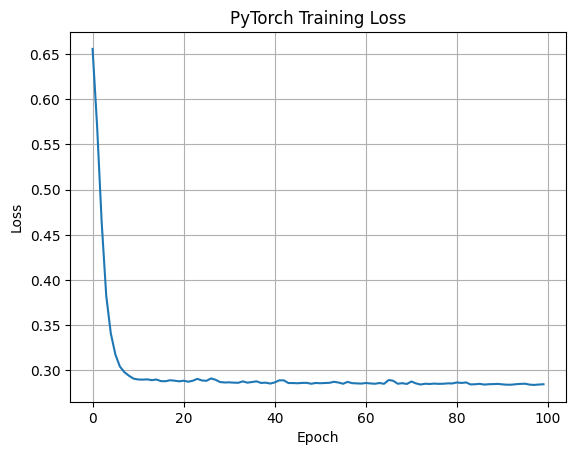

In [45]:
import torch
from torch.utils.data import TensorDataset, DataLoader

import torch.nn as nn
import torch.optim as optim

# Use existing numpy arrays from the notebook: X_train, y_train, X_test, y_test
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch_model = nn.Sequential(
	nn.Linear(2, 10),
	nn.Sigmoid(),
	nn.Linear(10, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

epochs = 100
train_losses = []

for epoch in range(epochs):
	torch_model.train()
	epoch_loss = 0.0
	
	for xb, yb in train_loader:
		xb, yb = xb.to(device), yb.to(device)
		
		optimizer.zero_grad()
		logits = torch_model(xb)
		loss = criterion(logits, yb)
		loss.backward()
		optimizer.step()
		
		epoch_loss += loss.item()

	train_losses.append(epoch_loss / len(train_loader))

# Evaluation
torch_model.eval()
with torch.no_grad():
	train_logits = torch_model(X_train_t.to(device))
	test_logits = torch_model(X_test_t.to(device))

	train_pred = (torch.sigmoid(train_logits) >= 0.5).float()
	test_pred = (torch.sigmoid(test_logits) >= 0.5).float()

	train_acc = (train_pred.cpu() == y_train_t).float().mean().item()
	test_acc = (test_pred.cpu() == y_test_t).float().mean().item()

print(f"PyTorch Train Accuracy: {train_acc:.4f}")
print(f"PyTorch Test Accuracy:  {test_acc:.4f}")

plt.plot(train_losses)
plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Training device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Epoch 001/100 | Loss: 0.6676 | Acc: 0.6088
Epoch 002/100 | Loss: 0.5754 | Acc: 0.8013
Epoch 003/100 | Loss: 0.4702 | Acc: 0.8087
Epoch 004/100 | Loss: 0.3909 | Acc: 0.8300
Epoch 005/100 | Loss: 0.3493 | Acc: 0.8387
Epoch 006/100 | Loss: 0.3229 | Acc: 0.8488
Epoch 007/100 | Loss: 0.3081 | Acc: 0.8600
Epoch 008/100 | Loss: 0.2988 | Acc: 0.8625
Epoch 009/100 | Loss: 0.2932 | Acc: 0.8600
Epoch 010/100 | Loss: 0.2912 | Acc: 0.8612
Epoch 011/100 | Loss: 0.2910 | Acc: 0.8700
Epoch 012/100 | Loss: 0.2889 | Acc: 0.8650
Epoch 013/100 | Loss: 0.2899 | Acc: 0.8688
Epoch 014/100 | Loss: 0.2887 | Acc: 0.8662
Epoch 015/100 | Loss: 0.2882 | Acc: 0.8712
Epoch 016/100 | Loss: 0.2900 | Acc: 0.8650
Epoch 017/100 | Loss: 0.2883 | Acc: 0.8650
Epoch 018/100 | Loss: 0.2875 | Acc: 0.8725
Epoch 019/100 | Loss: 0.2875 | Acc: 0.8675
Epoch 020/100 | Loss: 0.2876 | Acc: 0.8725
Epoch 021/100 | Loss: 0.2889 | Acc: 0.8612
Epoch 022/100 | Loss: 0.2870 | Acc:

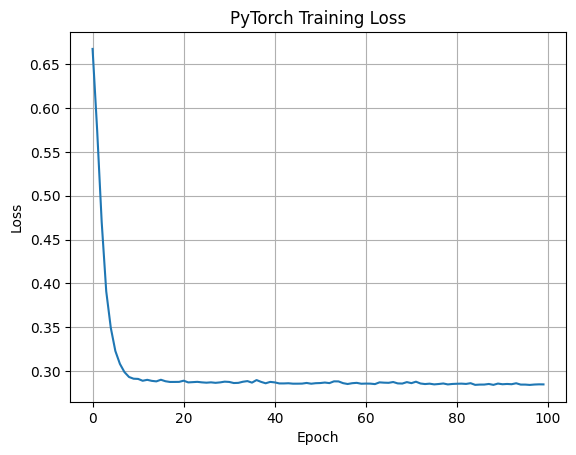

In [46]:
# Reuse X_train, y_train, X_test, y_test from previous cells

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, training on CPU.")

torch_model = nn.Sequential(
    nn.Linear(2, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

epochs = 100
train_losses = []

for epoch in range(epochs):
    torch_model.train()
    epoch_loss = 0.0
    correct, total = 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = torch_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    avg_loss = epoch_loss / len(train_loader)
    train_acc_epoch = correct / total
    train_losses.append(avg_loss)

    # Verbose output per epoch
    print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {train_acc_epoch:.4f}")

# Evaluation
torch_model.eval()
with torch.no_grad():
    train_logits = torch_model(X_train_t.to(device))
    test_logits = torch_model(X_test_t.to(device))

    train_pred = (torch.sigmoid(train_logits) >= 0.5).float()
    test_pred = (torch.sigmoid(test_logits) >= 0.5).float()

    train_acc = (train_pred.cpu() == y_train_t).float().mean().item()
    test_acc = (test_pred.cpu() == y_test_t).float().mean().item()

print(f"\nFinal PyTorch Train Accuracy: {train_acc:.4f}")
print(f"Final PyTorch Test Accuracy:  {test_acc:.4f}")
print(f"Model trained on: {'GPU' if device.type == 'cuda' else 'CPU'}")

plt.plot(train_losses)
plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)